In [ ]:
!pip install ultralytics opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.7 MB/s eta 0:00:00


In [ ]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# 🔥 YOLOv8 Segmentation Model
model = YOLO("yolov8n-seg.pt")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


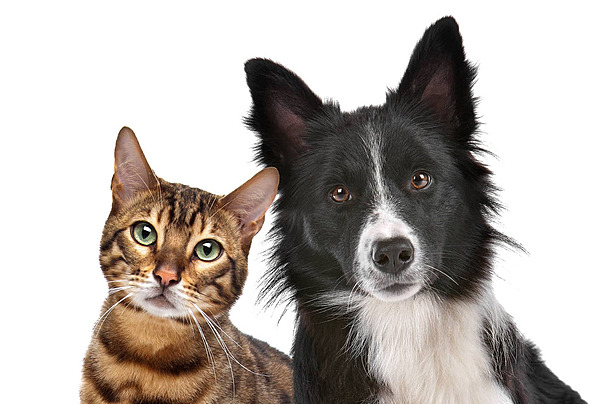

In [ ]:
img = cv2.imread("pngtree-dog-and-cat.jpg")

if img is None:
    raise ValueError("❌ Image not found")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2_imshow(img)


In [ ]:
results = model.predict(
    img,
    conf=0.3
)

result = results[0]



0: 448x640 1 cat, 1 dog, 328.8ms
Speed: 8.1ms preprocess, 328.8ms inference, 8.0ms postprocess per image at shape (1, 3, 448, 640)


In [ ]:
output = img.copy()

if result.masks is not None and result.boxes is not None:
    masks = result.masks.data.cpu().numpy()
    boxes = result.boxes.xyxy.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()

    num_instances = len(boxes)

    for i in range(num_instances):

        # Random unique color
        color = [random.randint(50,255) for _ in range(3)]

        mask = masks[i]
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]))
        mask = mask > 0.5

        # Apply mask
        output[mask] = (
            output[mask] * 0.4 + np.array(color) * 0.6
        ).astype(np.uint8)

        # Bounding box
        x1, y1, x2, y2 = map(int, boxes[i])
        cls = int(classes[i])
        label = model.names[cls]
        conf = confs[i]

        cv2.rectangle(output, (x1,y1), (x2,y2), color, 2)
        cv2.putText(
            output,
            f"{label} {conf:.2f}",
            (x1, y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )


(np.float64(-0.5), np.float64(605.5), np.float64(403.5), np.float64(-0.5))

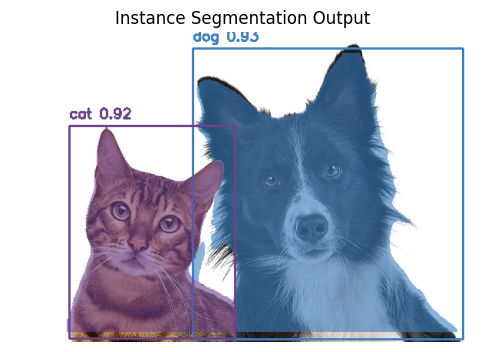

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Instance Segmentation Output")
plt.axis("off")


In [ ]:
cv2.imwrite("instance_seg_output.jpg", output)
print("✅ Instance segmentation image saved")
